In [1]:
import os
import warnings

import librosa
import librosa.display

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.21.0


In [2]:
# Dataset Folder
DATASET_PATH = "../dataset"

# Output folders
MODEL_DIR = "../models"
OUTPUT_DIR = "../outputs"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Dataset Path :", DATASET_PATH)
print("Model Folder :", MODEL_DIR)
print("Output Folder :", OUTPUT_DIR)

Dataset Path : ../dataset
Model Folder : ../models
Output Folder : ../outputs


In [3]:
audio_files = []

for actor in sorted(os.listdir(DATASET_PATH)):
    
    actor_path = os.path.join(DATASET_PATH, actor)
    
    if os.path.isdir(actor_path):
        
        for file in os.listdir(actor_path):
            
            if file.endswith(".wav"):
                
                audio_files.append(os.path.join(actor_path, file))

print("Total Audio Files :", len(audio_files))

print("\nFirst Five Files\n")

for file in audio_files[:5]:
    print(file)

Total Audio Files : 1440

First Five Files

../dataset\Actor_01\03-01-01-01-01-01-01.wav
../dataset\Actor_01\03-01-01-01-01-02-01.wav
../dataset\Actor_01\03-01-01-01-02-01-01.wav
../dataset\Actor_01\03-01-01-01-02-02-01.wav
../dataset\Actor_01\03-01-02-01-01-01-01.wav


In [4]:
emotion_dict = {
    "01": "Neutral",
    "02": "Calm",
    "03": "Happy",
    "04": "Sad",
    "05": "Angry",
    "06": "Fear",
    "07": "Disgust",
    "08": "Surprised"
}

In [5]:
filepaths = []
emotions = []

for path in audio_files:

    filename = os.path.basename(path)

    emotion_code = filename.split("-")[2]

    emotion = emotion_dict[emotion_code]

    filepaths.append(path)
    emotions.append(emotion)

df = pd.DataFrame({
    "Filepath": filepaths,
    "Emotion": emotions
})

print("Dataset Shape :", df.shape)

df.head()

Dataset Shape : (1440, 2)


,Filepath,Emotion
0,../dataset\Actor_01\03-01-01-01-01-01-01.wav,Neutral
1,../dataset\Actor_01\03-01-01-01-01-02-01.wav,Neutral
2,../dataset\Actor_01\03-01-01-01-02-01-01.wav,Neutral
3,../dataset\Actor_01\03-01-01-01-02-02-01.wav,Neutral
4,../dataset\Actor_01\03-01-02-01-01-01-01.wav,Calm


In [6]:
print("Dataset Information\n")
print(df.info())

print("\nEmotion Counts\n")
print(df["Emotion"].value_counts())

Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Filepath  1440 non-null   object
 1   Emotion   1440 non-null   object
dtypes: object(2)
memory usage: 22.6+ KB
None

Emotion Counts

Emotion
Calm         192
Happy        192
Sad          192
Angry        192
Disgust      192
Fear         192
Surprised    192
Neutral       96
Name: count, dtype: int64


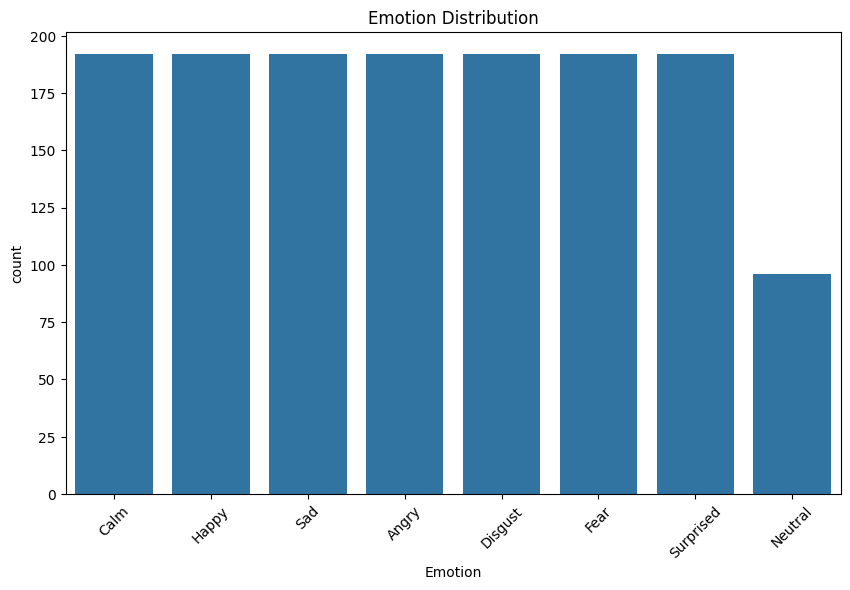

In [7]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Emotion",
    order=df["Emotion"].value_counts().index
)

plt.title("Emotion Distribution")
plt.xticks(rotation=45)

plt.savefig("../outputs/class_distribution.png")

plt.show()

In [8]:
sample_path = df.iloc[0]["Filepath"]

audio, sr = librosa.load(sample_path, sr=16000)

print("Sample File")
print(sample_path)

print("\nSampling Rate :", sr)

print("Audio Shape :", audio.shape)

print("Duration :", len(audio)/sr, "seconds")

Sample File
../dataset\Actor_01\03-01-01-01-01-01-01.wav

Sampling Rate : 16000
Audio Shape : (52853,)
Duration : 3.3033125 seconds


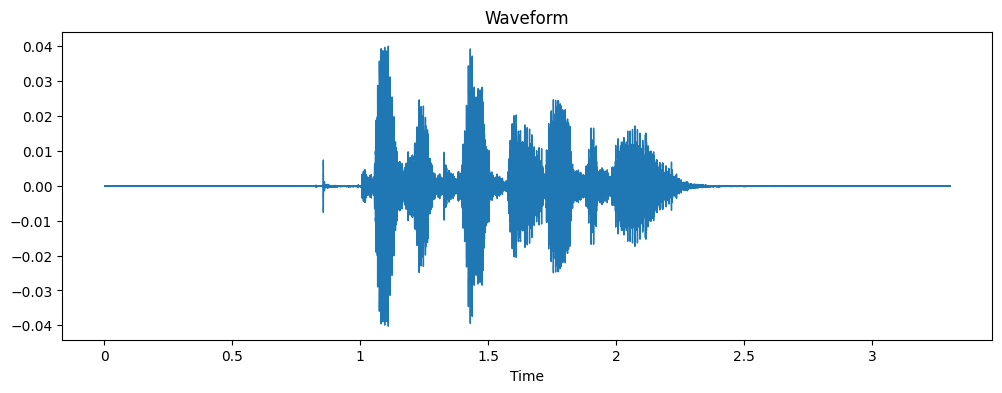

In [9]:
plt.figure(figsize=(12,4))

librosa.display.waveshow(audio, sr=sr)

plt.title("Waveform")

plt.show()

In [10]:
MAX_PAD_LEN = 180

def extract_features(file_path):

    audio, sr = librosa.load(file_path, sr=16000)

    # Normalize audio
    audio = librosa.util.normalize(audio)

    # Extract MFCCs
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40,
        n_fft=2048,
        hop_length=512
    )

    # Transpose so shape becomes (time_steps, features)
    mfcc = mfcc.T

    return mfcc

In [11]:
sample_feature = extract_features(sample_path)

print("MFCC Shape :", sample_feature.shape)

print("\nFirst Five Rows\n")

print(sample_feature[:5])

MFCC Shape : (104, 40)

First Five Rows

[[-559.11755    0.         0.         0.         0.         0.
     0.         0.         0.         0.         0.         0.
     0.         0.         0.         0.         0.         0.
     0.         0.         0.         0.         0.         0.
     0.         0.         0.         0.         0.         0.
     0.         0.         0.         0.         0.         0.
     0.         0.         0.         0.     ]
 [-559.11755    0.         0.         0.         0.         0.
     0.         0.         0.         0.         0.         0.
     0.         0.         0.         0.         0.         0.
     0.         0.         0.         0.         0.         0.
     0.         0.         0.         0.         0.         0.
     0.         0.         0.         0.         0.         0.
     0.         0.         0.         0.     ]
 [-559.11755    0.         0.         0.         0.         0.
     0.         0.         0.         0.      

In [12]:
X = []
y = []

print("Extracting MFCC Features...\n")

for _, row in tqdm(df.iterrows(), total=len(df)):

    features = extract_features(row["Filepath"])

    X.append(features)

    y.append(row["Emotion"])

print("\nFeature Extraction Completed!")

print("\nTotal Samples :", len(X))

print("Total Labels :", len(y))

print("\nExample Feature Shape :", X[0].shape)

Extracting MFCC Features...



100%|██████████| 1440/1440 [00:24<00:00, 59.19it/s]


Feature Extraction Completed!

Total Samples : 1440
Total Labels : 1440

Example Feature Shape : (104, 40)


In [13]:
# Find the longest sequence

max_length = max(feature.shape[0] for feature in X)

print("Maximum Sequence Length :", max_length)

Maximum Sequence Length : 165


In [14]:
# Pad all sequences to the same length

X_padded = pad_sequences(
    X,
    maxlen=max_length,
    dtype="float32",
    padding="post",
    truncating="post"
)

print("Padded Feature Shape :", X_padded.shape)

Padded Feature Shape : (1440, 165, 40)


In [15]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Emotion Classes\n")

for emotion, label in zip(label_encoder.classes_,
                          label_encoder.transform(label_encoder.classes_)):
    print(f"{emotion:12s} -> {label}")

Emotion Classes

Angry        -> 0
Calm         -> 1
Disgust      -> 2
Fear         -> 3
Happy        -> 4
Neutral      -> 5
Sad          -> 6
Surprised    -> 7


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_padded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (1152, 165, 40)
Testing Samples : (288, 165, 40)


In [17]:
model = Sequential([

    LSTM(
        128,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),

    Dropout(0.3),

    LSTM(64),

    Dropout(0.3),

    Dense(64, activation="relu"),

    Dropout(0.2),

    Dense(len(label_encoder.classes_), activation="softmax")

])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 165, 128)            │          86,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 165, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             520 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 140,616 (549.28 KB)

 Trainable params: 140,616 (549.28 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(

    X_train,

    y_train,

    validation_split=0.2,

    epochs=40,

    batch_size=32,

    callbacks=[early_stop],

    verbose=1

)

Epoch 1/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 138ms/step - accuracy: 0.1488 - loss: 2.0465 - val_accuracy: 0.2554 - val_loss: 1.9616
Epoch 2/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.2226 - loss: 1.9603 - val_accuracy: 0.2511 - val_loss: 1.8209
Epoch 3/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - accuracy: 0.3008 - loss: 1.7828 - val_accuracy: 0.2727 - val_loss: 1.8499
Epoch 4/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.3084 - loss: 1.7533 - val_accuracy: 0.3333 - val_loss: 1.7268
Epoch 5/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.3138 - loss: 1.6797 - val_accuracy: 0.3377 - val_loss: 1.7310
Epoch 6/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - accuracy: 0.3388 - loss: 1.6132 - val_accuracy: 0.3333 - val_loss: 1.7157
Epoch 7/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.3648 - loss: 1.5870 - val_accuracy: 0.3247 - val_loss: 1.7873
Epoch 8/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.4028 - loss: 1.5235 - val_accuracy: 0.

In [19]:
model.save("../models/speech_emotion_lstm.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


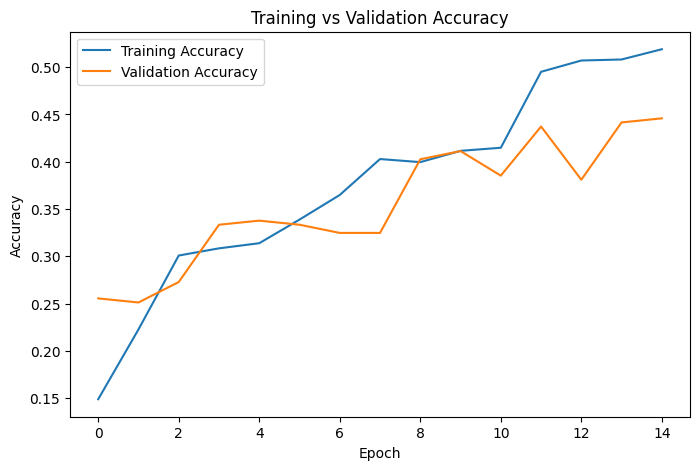

In [20]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("../outputs/accuracy_plot.png")

plt.show()

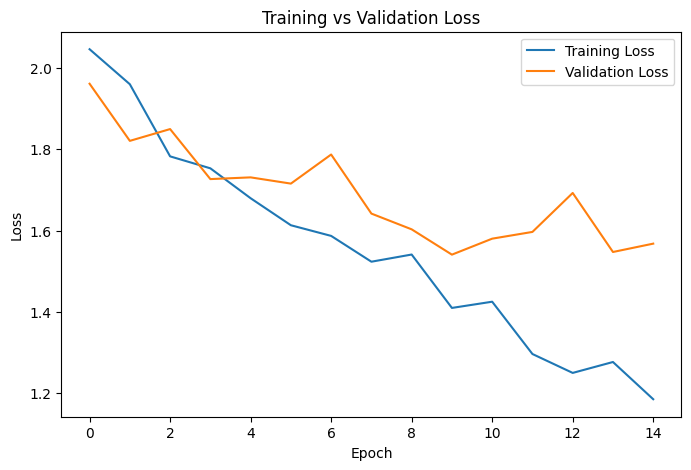

In [21]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig("../outputs/loss_plot.png")

plt.show()

In [22]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

Test Loss     : 1.6892
Test Accuracy : 0.3090


In [23]:
y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

print("Prediction Shape:", y_pred.shape)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
Prediction Shape: (288,)


In [24]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.3090
Precision: 0.2978
Recall   : 0.3090
F1 Score : 0.2966


In [25]:
report = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
)

print(report)

with open("../outputs/classification_report.txt", "w") as f:
    f.write(report)

              precision    recall  f1-score   support

       Angry       0.28      0.24      0.26        38
        Calm       0.45      0.47      0.46        38
     Disgust       0.37      0.42      0.40        38
        Fear       0.14      0.05      0.08        39
       Happy       0.19      0.21      0.20        39
     Neutral       0.19      0.42      0.26        19
         Sad       0.16      0.13      0.14        38
   Surprised       0.55      0.59      0.57        39

    accuracy                           0.31       288
   macro avg       0.29      0.32      0.29       288
weighted avg       0.30      0.31      0.30       288



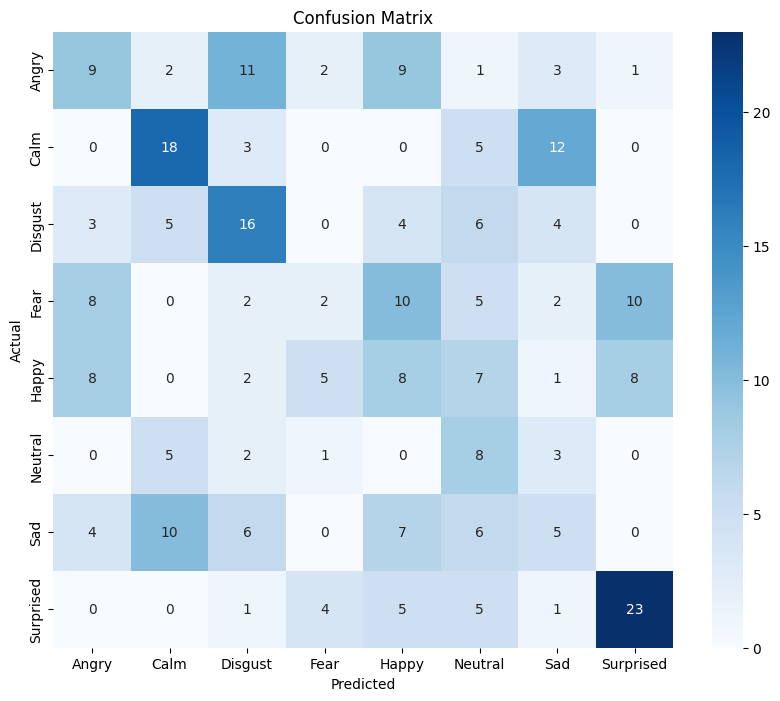

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("../outputs/confusion_matrix.png")

plt.show()

In [27]:
history_df = pd.DataFrame(history.history)

history_df.to_csv(
    "../outputs/training_history.csv",
    index=False
)

print("Training history saved.")

Training history saved.


In [28]:
print("="*50)
print("Speech Emotion Recognition using LSTM")
print("="*50)

print(f"Total Samples      : {len(df)}")
print(f"Training Samples   : {len(X_train)}")
print(f"Testing Samples    : {len(X_test)}")
print(f"Number of Classes  : {len(label_encoder.classes_)}")

print("\nEvaluation Metrics")
print("---------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nModel saved to:")
print("../models/speech_emotion_lstm.keras")

print("\nOutputs saved to ../outputs/")
print("="*50)

Speech Emotion Recognition using LSTM
Total Samples      : 1440
Training Samples   : 1152
Testing Samples    : 288
Number of Classes  : 8

Evaluation Metrics
---------------------
Accuracy  : 0.3090
Precision : 0.2978
Recall    : 0.3090
F1 Score  : 0.2966

Model saved to:
../models/speech_emotion_lstm.keras

Outputs saved to ../outputs/
